# Imports (Directly copy and pasted)

In [1]:
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence


from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Graph

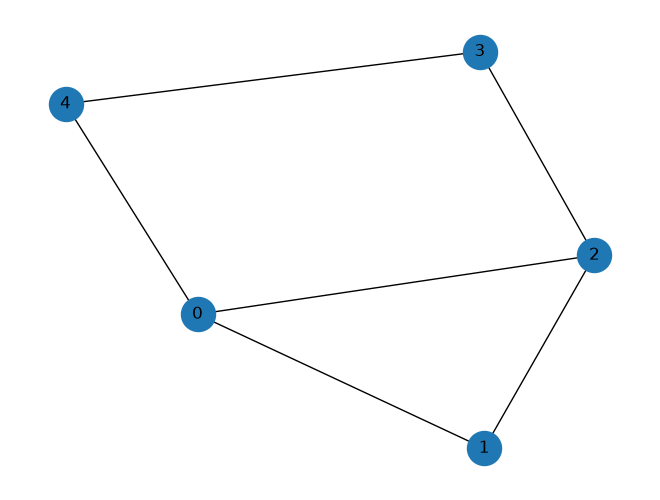

In [2]:
graph_nodes = 5

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, graph_nodes, 1))
edge_list = [
    (0, 1, 1.0),
    (0, 2, 1.0),
    (0, 4, 1.0),
    (1, 2, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

# Building the Hamiltonian

In [3]:
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, list[int], float]]:
    # Basically we encode every edge in I and Z gates. 
    # I'm not 100% sure why this works still
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list

max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, graph_nodes)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


# Making the Circuit (Thanks to qiskit for automating this)

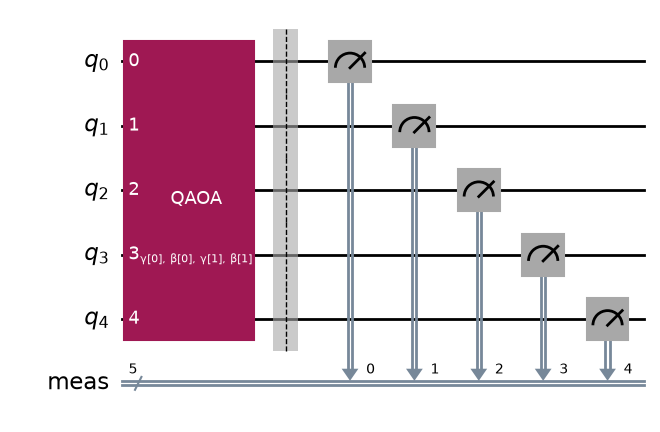

In [4]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()
circuit.draw("mpl")

In [5]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

# Now we let qiskit do the heavy lifting in making our circuit

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="VCOTZ6Gp-lC87iRtXuO7UEYHw4ZOz2tKlxV7jMZpokmv", 
    overwrite=True, 
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/407ca19e17a241c49d094e4d01c47f57:61b62a1b-fdd6-4425-92d0-502f8dd00f40::", 
    set_as_default=True
)


<IBMBackend('ibm_kingston')>


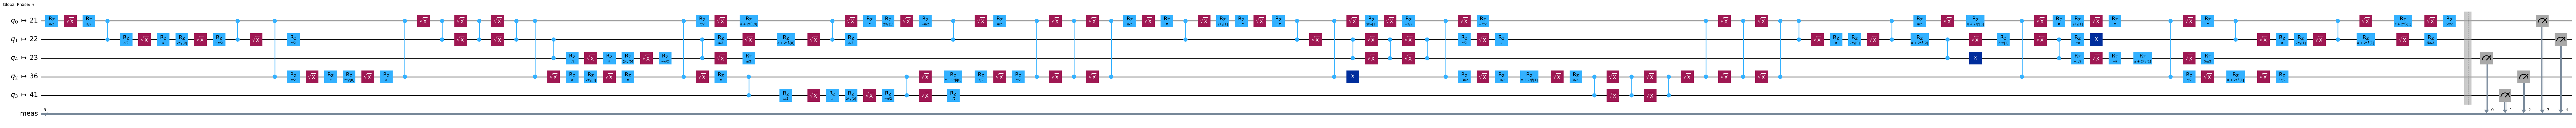

In [7]:
import os
os.environ.pop("QISKIT_IBM_TOKEN", None)
os.environ.pop("QISKIT_IBM_INSTANCE", None)
os.environ.pop("QISKIT_IBM_CHANNEL", None)

service = QiskitRuntimeService(
    #channel="ibm_quantum_platform",
    #token="VCOTZ6Gp-lC87iRtXuO7UEYHw4ZOz2tKlxV7jMZpokmv",
    #instance="crn:v1:bluemix:public:quantum-computing:us-east:a/407ca19e17a241c49d094e4d01c47f57:61b62a1b-fdd6-4425-92d0-502f8dd00f40::"
)
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

# Create pass manager for transpilation. Level 3 is the most aggressive
# preset: slower to transpile, but produces shorter circuits that are
# more robust to hardware noise.
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)


# Looks like I can't run this on an open plan. Thanks a lot IBM

In [14]:
from qiskit_aer import AerSimulator
aer_backend = AerSimulator()


# More Tutorial

In [9]:
initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

In [10]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

In [16]:
objective_func_vals = []  # Global variable
with Session(backend=aer_backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    estimator.options.environment.job_tags = ["TUT_QAOA"]

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.798201798201798
       x: [ 1.546e+00  2.657e+00  3.220e+00  3.286e+00]
    nfev: 25
   maxcv: 0.0


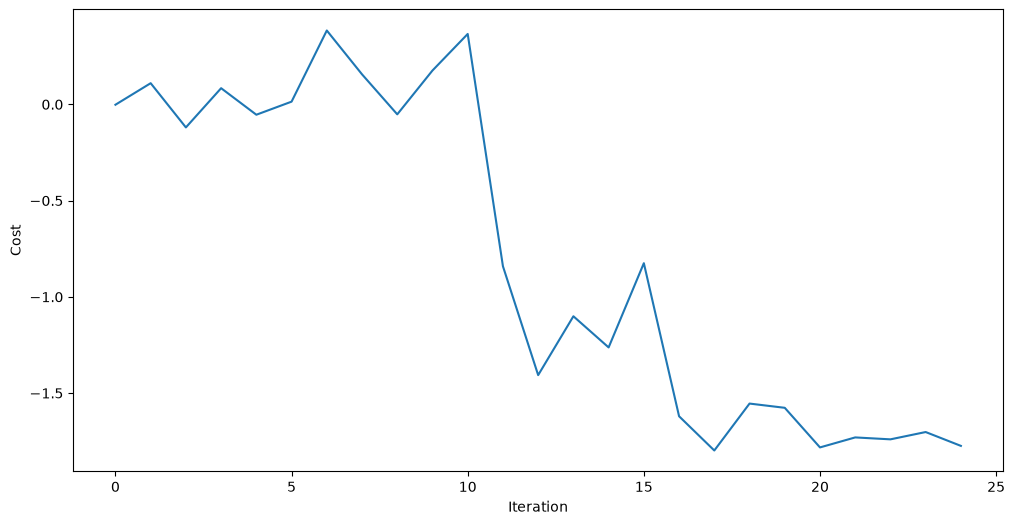

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

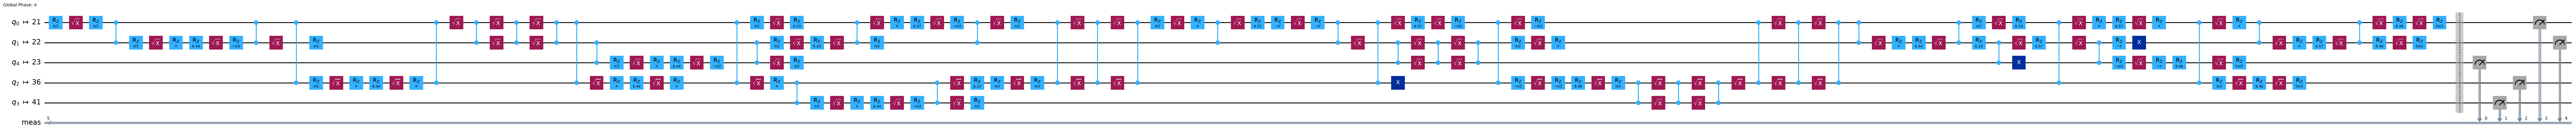

In [18]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

In [20]:
# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=aer_backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

sampler.options.environment.job_tags = ["TUT_QAOA"]

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

{9: 0.0923, 1: 0.0197, 20: 0.0878, 26: 0.0532, 10: 0.0433, 11: 0.0879, 2: 0.0118, 25: 0.0174, 3: 0.0172, 13: 0.0457, 27: 0.0242, 30: 0.0206, 21: 0.0433, 17: 0.0213, 22: 0.0922, 6: 0.0197, 18: 0.0477, 0: 0.0085, 23: 0.0129, 16: 0.0124, 5: 0.0522, 8: 0.0129, 19: 0.0198, 31: 0.0103, 4: 0.0249, 7: 0.0068, 15: 0.0133, 29: 0.0097, 12: 0.0221, 28: 0.0203, 14: 0.0236, 24: 0.005}


/home/matthman2019/PythonProjects/Quantum/.venv/lib/python3.14/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


In [21]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [1, 0, 0, 1, 0]


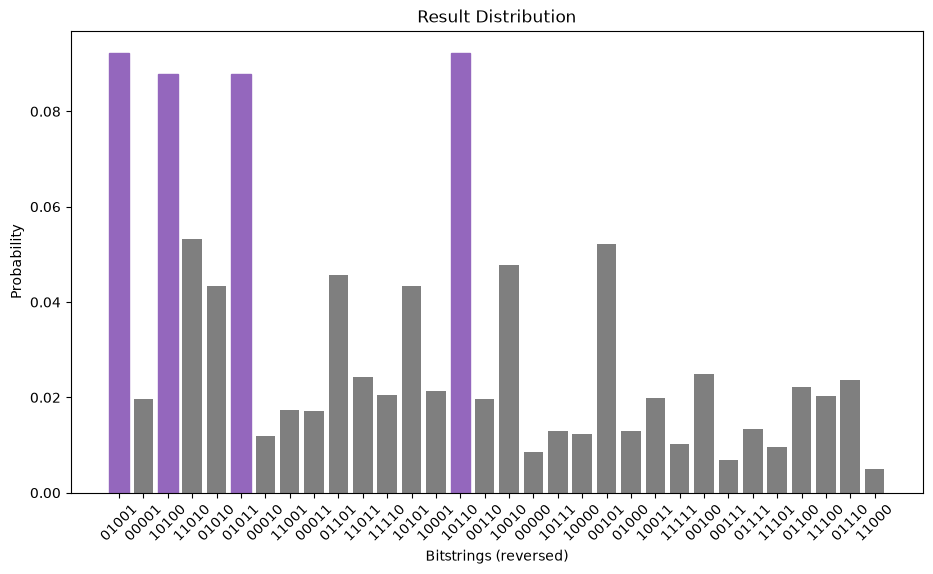

In [22]:
plt.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()